# Titanic Dataset Analysis Project

## Overview

The Titanic Dataset Analysis project involves exploring and analyzing the Titanic dataset to understand various factors that influenced passenger survival during the tragic sinking of the RMS Titanic. This dataset, sourced from OpenML, contains passenger information including age, sex, ticket class, and survival status.

## Objectives

### Data Exploration and Preprocessing

- Load and inspect the Titanic dataset.
- Clean the dataset by handling missing values and removing irrelevant features.
- Convert categorical variables into numeric format for analysis.

### Exploratory Data Analysis (EDA)

- Analyze the distribution of survival rates.
- Examine the distribution of passenger ages and fares.
- Investigate survival rates across different genders, embarkation points, age groups, and fare ranges.
- Visualize relationships between features using correlation matrices and pairplots.

### Feature Engineering

- Create new features such as age groups and fare ranges to enhance the analysis.
- Analyze feature importance to understand the impact of various factors on survival rates.

### Model Building and Evaluation

- Build and evaluate predictive models using Random Forest and Gradient Boosting classifiers.
- Use pipelines for preprocessing and model evaluation.
- Assess model performance through confusion matrices and classification reports.

## Methods and Tools

### Libraries Used

- `pandas` for data manipulation and analysis.
- `numpy` for numerical operations.
- `seaborn` and `matplotlib` for data visualization.
- `sklearn` for machine learning algorithms and preprocessing.

### Techniques

- **Data Cleaning:** Filling missing values and feature encoding.
- **EDA:** Visualizations and statistical summaries to explore data patterns.
- **Feature Engineering:** Creating meaningful features for improved analysis.
- **Model Evaluation:** Comparing different classification models to predict survival.

This project provides a comprehensive approach to understanding the factors that contributed to survival on the Titanic and demonstrates the use of machine learning techniques for predictive analysis.


   pclass survived                                             name     sex  \
0       1        1                    Allen, Miss. Elisabeth Walton  female   
1       1        1                   Allison, Master. Hudson Trevor    male   
2       1        0                     Allison, Miss. Helen Loraine  female   
3       1        0             Allison, Mr. Hudson Joshua Creighton    male   
4       1        0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    NaN   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.0000      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0                     St Louis,

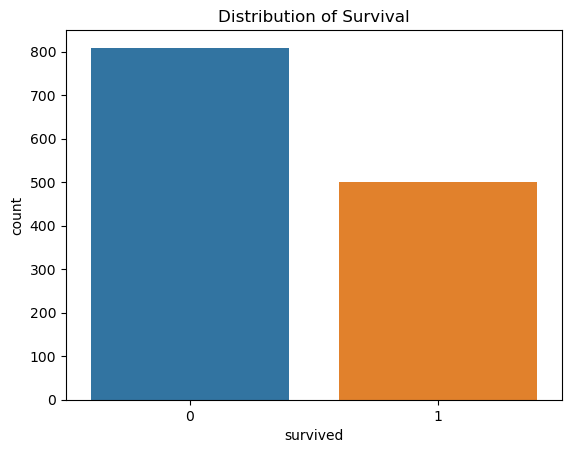

C:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


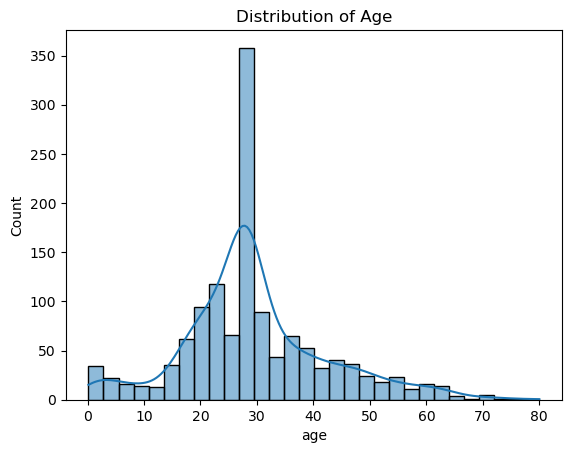

C:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


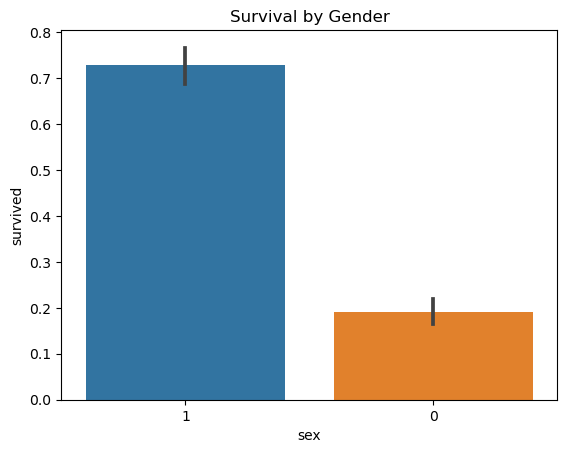

C:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


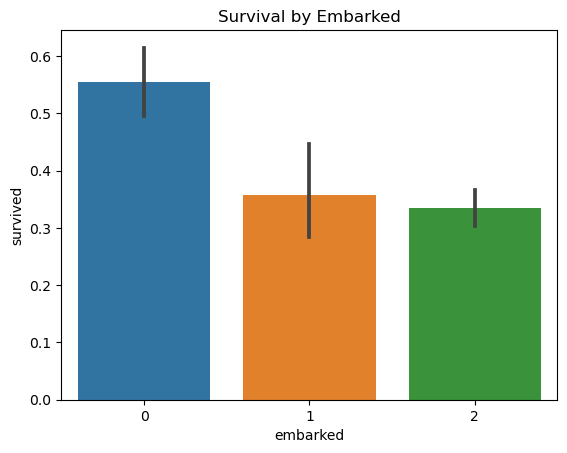

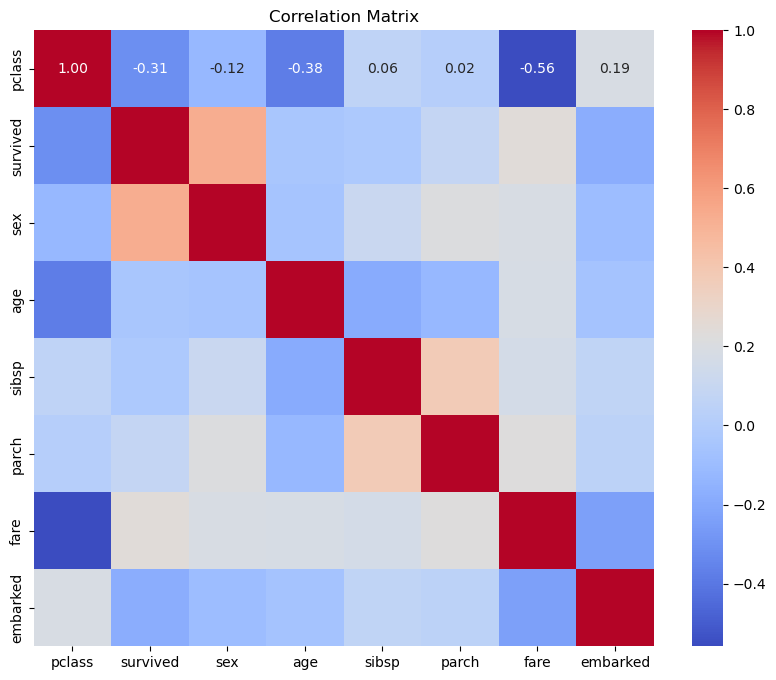

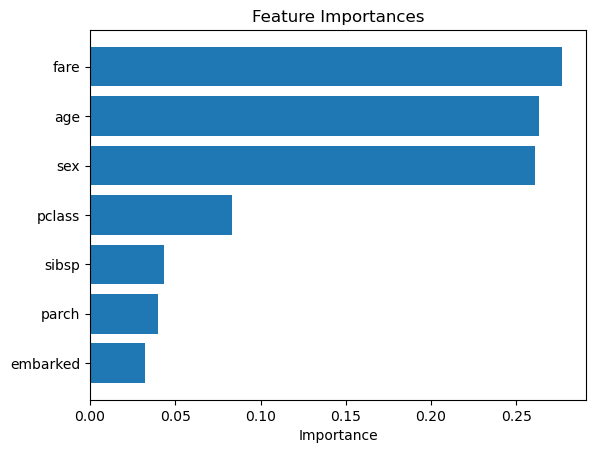

C:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


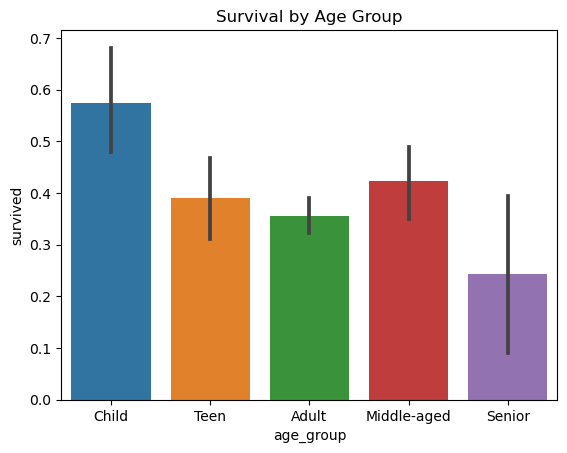

C:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


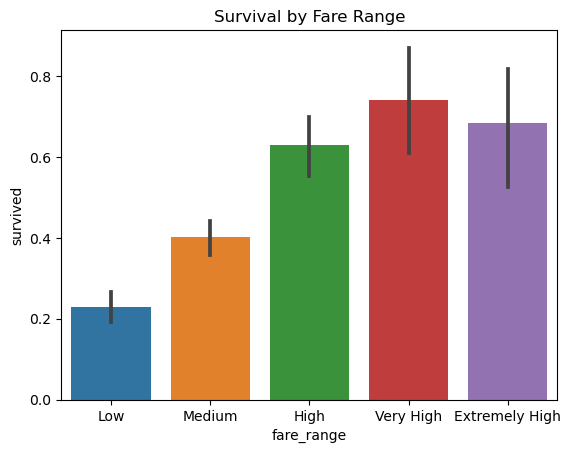

C:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


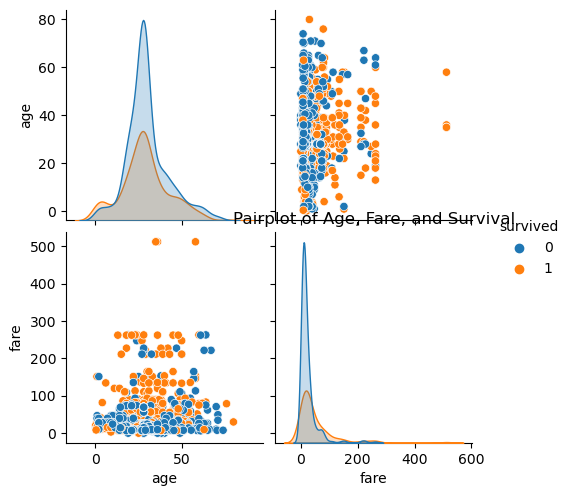

Evaluating RandomForest model...

RandomForest Model Evaluation:
[[190  34]
 [ 56 113]]
              precision    recall  f1-score   support

           0       0.77      0.85      0.81       224
           1       0.77      0.67      0.72       169

    accuracy                           0.77       393
   macro avg       0.77      0.76      0.76       393
weighted avg       0.77      0.77      0.77       393

Evaluating GradientBoosting model...

GradientBoosting Model Evaluation:
[[198  26]
 [ 61 108]]
              precision    recall  f1-score   support

           0       0.76      0.88      0.82       224
           1       0.81      0.64      0.71       169

    accuracy                           0.78       393
   macro avg       0.79      0.76      0.77       393
weighted avg       0.78      0.78      0.77       393



In [9]:
# Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# Load Titanic dataset from sklearn
titanic = fetch_openml(name='titanic', version=1, as_frame=True)
df = titanic.frame

# Display the first few rows and check the columns
print(df.head())
print(df.columns)

# Data Preprocessing

# Fill missing values
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df['fare'].fillna(df['fare'].median(), inplace=True)

# Drop columns that are not needed for the model
df.drop(columns=['cabin', 'ticket', 'name', 'boat', 'body', 'home.dest'], inplace=True)

# Convert categorical columns to numeric
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'C': 0, 'Q': 1, 'S': 2})

# Ensure that the target variable is numeric
df['survived'] = df['survived'].astype(int)

# Exploratory Data Analysis (EDA)

# Distribution of Survival
sns.countplot(x='survived', data=df)
plt.title('Distribution of Survival')
plt.show()

# Distribution of Age
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.show()

# Survival by Gender
sns.barplot(x='sex', y='survived', data=df)
plt.title('Survival by Gender')
plt.show()

# Survival by Embarked
sns.barplot(x='embarked', y='survived', data=df)
plt.title('Survival by Embarked')
plt.show()

# Correlation Analysis
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Feature Importance
X = df.drop('survived', axis=1)
y = df['survived']
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure()
plt.title('Feature Importances')
plt.barh(range(X.shape[1]), importances[indices], align='center')
plt.yticks(range(X.shape[1]), X.columns[indices])
plt.xlabel('Importance')
plt.show()

# Advanced Analysis

# Survival by Age Group
df['age_group'] = pd.cut(df['age'], bins=[0, 12, 20, 40, 60, 100], labels=['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior'])
sns.barplot(x='age_group', y='survived', data=df)
plt.title('Survival by Age Group')
plt.show()

# Survival by Fare Range
df['fare_range'] = pd.cut(df['fare'], bins=[0, 10, 50, 100, 200, 600], labels=['Low', 'Medium', 'High', 'Very High', 'Extremely High'])
sns.barplot(x='fare_range', y='survived', data=df)
plt.title('Survival by Fare Range')
plt.show()

# Pairplot
sns.pairplot(df[['age', 'fare', 'survived']], hue='survived')
plt.title('Pairplot of Age, Fare, and Survival')
plt.show()

# Model Building and Evaluation

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Creating pipelines for preprocessing and modeling
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['age', 'fare']),
        ('cat', OneHotEncoder(), ['sex', 'embarked'])
    ])

models = {
    'RandomForest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'GradientBoosting': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ])
}

for name, model in models.items():
    print(f"Evaluating {name} model...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n{name} Model Evaluation:")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
